# 후보 모델 탐색 — Lot 패턴 분류 + 위험 vs 안전 분포

`C:/Users/Dell3571/Downloads/best` 의 후보 run(a/b/c)을 골라가며 대시보드용 두 차트를 미리 본다.
- **Part A**: lot별 패턴 분류(NearFull/Edge/Center/Random/Normal) + 웨이퍼맵, 그리고 **RATIO·threshold 실험**
- **Part B**: 공정인자 위험(상위10%) vs 안전(하위10%) 피처 분포

분류 로직·기준은 대시보드(`regen_pattern.py`, ProcessFactor)와 동일. `RUN_IDX`만 바꿔 후보 비교.

In [1]:
import re, json, pickle, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 모델 모듈 경로 (fold_models.pkl unpickle용)
sys.path.insert(0, 'C:/Users/Dell3571/Desktop/ASAC_SKhynix/3_modeling')
sys.path.insert(0, 'C:/Users/Dell3571/Desktop/ASAC_SKhynix')
XS_PATH = 'C:/Users/Dell3571/Desktop/ASAC_SKhynix/0_data/compet_xs_data.csv'

ROOT = Path('C:/Users/Dell3571/Downloads/best')
runs = sorted(ROOT.glob('*/*/best'))
for i, r in enumerate(runs):
    print(i, '|', r.parent.name)

RUN_IDX = 0          # <-- 후보 선택 (0,1,2)
BEST = runs[RUN_IDX]
print('\n선택:', BEST.parent.name)
rec = json.load(open(BEST / 'summary_record.json'))
print('seed:', rec.get('seed'), '| val_rmse:', round(rec.get('val_rmse', 0), 6))

0 | run_0605_193728 c
1 | run_0605_193735 b
2 | run_0605_193800 a

선택: run_0605_193728 c
seed: 1019 | val_rmse: 0.005698


## Part A. Lot 패턴 분류 + 웨이퍼맵

In [2]:
# die 데이터 로드 (oof+val+test) → pred=pred_taupi, run_wf_xy 파싱
die = pd.concat([pd.read_csv(BEST / f'{s}_die.csv') for s in ['oof', 'val', 'test']], ignore_index=True)
die['pred'] = pd.to_numeric(die['pred_taupi'], errors='coerce')
sp = die['run_wf_xy'].str.split('_', expand=True)
die['run_id'] = pd.to_numeric(sp[0], errors='coerce')
die['die_x']  = pd.to_numeric(sp.iloc[:, -2], errors='coerce')
die['die_y']  = pd.to_numeric(sp.iloc[:, -1], errors='coerce')
die = die.dropna(subset=['pred', 'run_id', 'die_x', 'die_y'])

THRESHOLD = float(die['pred'].quantile(0.90))   # 위험 임계값 = die pred 상위 10%(P90)
print(f'die {len(die):,}행 | lot {die.run_id.nunique()}개 | threshold(P90)={THRESHOLD:.6f}')

# lot별 좌표 max 집계 (계층탐색 lot맵과 동일)
lot_dies = {}
for lot, g in die.groupby('run_id'):
    coord = g.groupby(['die_x', 'die_y'], as_index=False)['pred'].max()
    lot_dies[int(lot)] = coord[['die_x', 'die_y', 'pred']].values
print('lot 수:', len(lot_dies))

die 174,572행 | lot 28개 | threshold(P90)=0.000852
lot 수: 28


In [3]:
# 분류 파라미터 (대시보드와 동일). ratio/nearfull은 함수 인자로도 바꿀 수 있음(실험용)
RATIO = 1.6; R_CENTER = 0.45; R_EDGE = 0.75; HIGH_RATIO = 0.10; NEARFULL = 0.55

def classify(dies, threshold, ratio=None, nearfull=None):
    ratio = RATIO if ratio is None else ratio
    nearfull = NEARFULL if nearfull is None else nearfull
    xs, ys, ps = dies[:, 0], dies[:, 1], dies[:, 2]
    cx = (xs.max() + xs.min()) / 2; cy = (ys.max() + ys.min()) / 2
    r = np.hypot(xs - cx, (ys - cy) * 2.5); rmax = r.max()
    if rmax == 0:
        return 'normal'
    rn = r / rmax
    high_ratio = (ps > threshold).mean()
    if high_ratio >= nearfull:                         # 1) NearFull
        return 'nearfull'
    cm = rn < R_CENTER; em = rn > R_EDGE
    if cm.sum() == 0 or em.sum() == 0:
        return 'normal' if high_ratio < HIGH_RATIO else 'random'
    c_avg = ps[cm].mean(); e_avg = ps[em].mean()
    if e_avg > c_avg * ratio and e_avg > threshold * 0.3:   # 2) Edge
        return 'edge'
    if c_avg > e_avg * ratio and c_avg > threshold * 0.3:   #    Center
        return 'center'
    return 'normal' if high_ratio < HIGH_RATIO else 'random'  # 3) Normal/Random

In [4]:
# 기본(RATIO=1.6, P90) 패턴 분포 + lot별 표
rows = []
for lot, d in sorted(lot_dies.items()):
    rows.append({'lot': lot, 'pattern': classify(d, THRESHOLD),
                 'risk_ratio': round(float((d[:, 2] > THRESHOLD).mean()), 3),
                 'n_dies': len(d), 'max_pred': round(float(d[:, 2].max()), 6)})
pat_df = pd.DataFrame(rows)
print('패턴 분포:', pat_df['pattern'].value_counts().to_dict())
pat_df.sort_values('risk_ratio', ascending=False)

패턴 분포: {'normal': 14, 'random': 9, 'nearfull': 3, 'edge': 2}


,lot,pattern,risk_ratio,n_dies,max_pred
24,24,nearfull,0.981,937,0.000944
7,7,nearfull,0.895,934,0.000946
3,3,nearfull,0.686,939,0.000913
5,5,random,0.528,933,0.000926
4,4,random,0.527,940,0.000910
16,16,random,0.517,917,0.000917
13,13,random,0.369,938,0.000965
6,6,random,0.240,906,0.000901
21,21,random,0.234,914,0.000896
12,12,random,0.160,923,0.000900


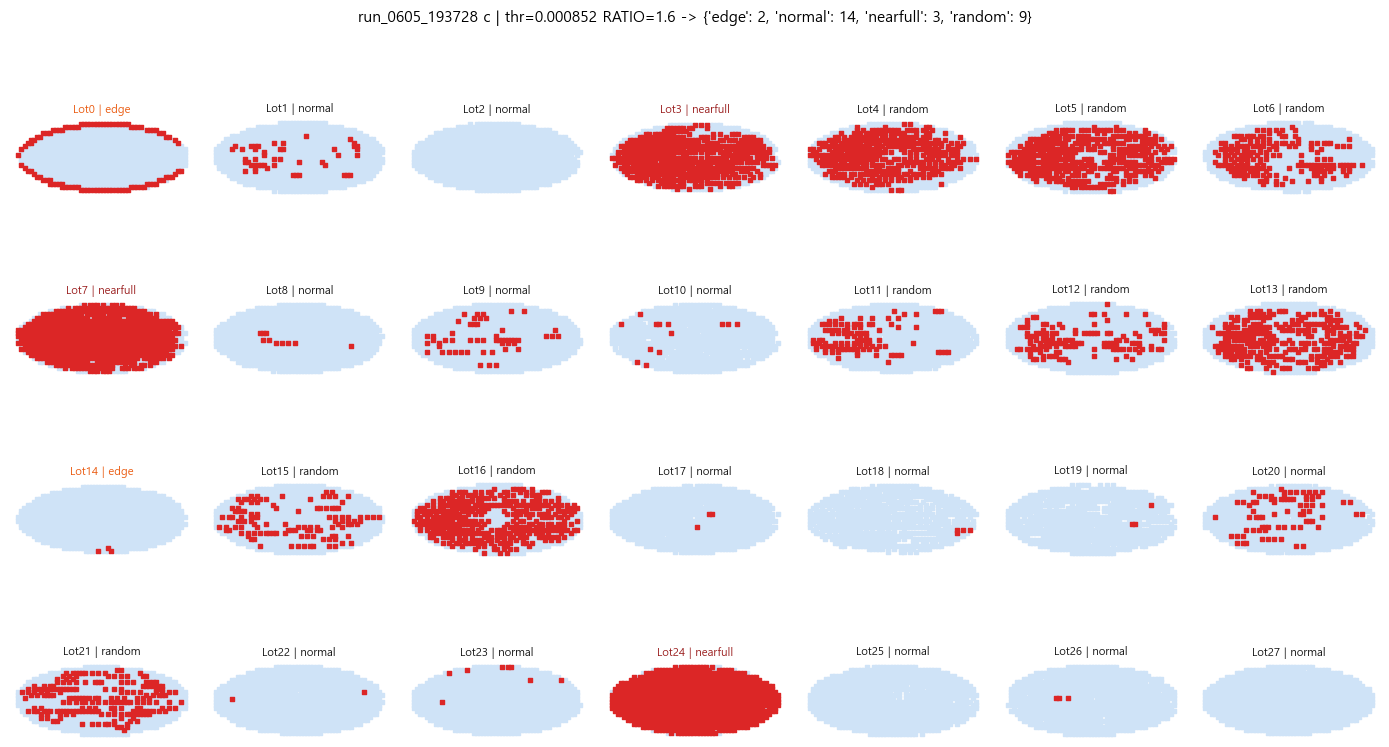

In [5]:
# lot 웨이퍼맵 (빨강=위험 die > threshold)
PAT_COLOR = {'nearfull': '#991B1B', 'edge': '#ea580c', 'center': '#d97706', 'random': '#111', 'normal': '#111'}

def draw_lot_maps(threshold=None, ratio=None, ncols=7):
    threshold = THRESHOLD if threshold is None else threshold
    lots = sorted(lot_dies)
    nrows = int(np.ceil(len(lots) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.0, nrows * 2.1))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        ax.axis('off')
    cnt = {}
    for ax, lot in zip(axes, lots):
        d = lot_dies[lot]; p = classify(d, threshold, ratio); cnt[p] = cnt.get(p, 0) + 1
        risk = d[:, 2] > threshold
        ax.scatter(d[~risk, 0], d[~risk, 1], c='#cfe3f7', s=7, marker='s')
        ax.scatter(d[risk, 0], d[risk, 1], c='#dc2626', s=7, marker='s')
        ax.set_title(f'Lot{lot} | {p}', fontsize=8, color=PAT_COLOR.get(p, '#111'))
        ax.set_aspect('equal'); ax.invert_yaxis(); ax.axis('off')
    rr = RATIO if ratio is None else ratio
    plt.suptitle(f'{BEST.parent.name} | thr={threshold:.6f} RATIO={rr} -> {cnt}', fontsize=11)
    plt.tight_layout(); plt.show()

draw_lot_maps()

### RATIO · threshold 실험

여러 RATIO와 threshold 조합에서 패턴 분포가 어떻게 바뀌는지 표로 본다. center/edge가 잘 잡히는 조합이 있는지 확인.

In [6]:
# RATIO × threshold sweep — 패턴 분포 표
ratios = [1.6, 1.4, 1.3, 1.2, 1.15, 1.1, 1.05]
q_list = [0.75, 0.85, 0.90, 0.95]
rows = []
for q in q_list:
    t = float(die['pred'].quantile(q))
    for R in ratios:
        cnt = {'nearfull': 0, 'edge': 0, 'center': 0, 'random': 0, 'normal': 0}
        for d in lot_dies.values():
            cnt[classify(d, t, R)] += 1
        rows.append({'thr_q': f'P{int(q*100)}', 'threshold': round(t, 6), 'RATIO': R, **cnt})
sweep = pd.DataFrame(rows)
print('center 또는 edge가 잡히는 조합:')
display(sweep[(sweep.center > 0) | (sweep.edge > 0)])
sweep

center 또는 edge가 잡히는 조합:


,thr_q,threshold,RATIO,nearfull,edge,center,random,normal
0,P75,0.000809,1.60,10,2,0,9,7
1,P75,0.000809,1.40,10,2,0,9,7
2,P75,0.000809,1.30,10,2,0,9,7
3,P75,0.000809,1.20,10,2,0,9,7
4,P75,0.000809,1.15,10,2,1,9,6
5,P75,0.000809,1.10,10,2,6,6,4
6,P75,0.000809,1.05,10,3,8,3,4
7,P85,0.000838,1.60,7,2,0,7,12
8,P85,0.000838,1.40,7,2,0,7,12
9,P85,0.000838,1.30,7,2,0,7,12


,thr_q,threshold,RATIO,nearfull,edge,center,random,normal
0,P75,0.000809,1.60,10,2,0,9,7
1,P75,0.000809,1.40,10,2,0,9,7
2,P75,0.000809,1.30,10,2,0,9,7
3,P75,0.000809,1.20,10,2,0,9,7
4,P75,0.000809,1.15,10,2,1,9,6
5,P75,0.000809,1.10,10,2,6,6,4
6,P75,0.000809,1.05,10,3,8,3,4
7,P85,0.000838,1.60,7,2,0,7,12
8,P85,0.000838,1.40,7,2,0,7,12
9,P85,0.000838,1.30,7,2,0,7,12


In [7]:
# center가 처음 나타나는 RATIO 진단 (threshold 무관 — center_avg/edge_avg 비율)
def ce_ratio(dies):
    xs, ys, ps = dies[:, 0], dies[:, 1], dies[:, 2]
    cx = (xs.max() + xs.min()) / 2; cy = (ys.max() + ys.min()) / 2
    r = np.hypot(xs - cx, (ys - cy) * 2.5); rmax = r.max()
    if rmax == 0: return np.nan
    rn = r / rmax; cm = rn < R_CENTER; em = rn > R_EDGE
    if cm.sum() == 0 or em.sum() == 0: return np.nan
    e = ps[em].mean();  return (ps[cm].mean() / e) if e else np.nan
ce = pd.DataFrame({'lot': list(lot_dies), 'center/edge': [round(ce_ratio(d), 2) for d in lot_dies.values()]})
print('center/edge 비율 상위 (이 값이 RATIO를 넘으면 center로 분류됨):')
ce.sort_values('center/edge', ascending=False).head(10)

center/edge 비율 상위 (이 값이 RATIO를 넘으면 center로 분류됨):


,lot,center/edge
26,26,1.20
27,27,1.13
1,1,1.12
17,17,1.12
2,2,1.11
8,8,1.10
20,20,1.09
15,15,1.07
9,9,1.07
7,7,1.04


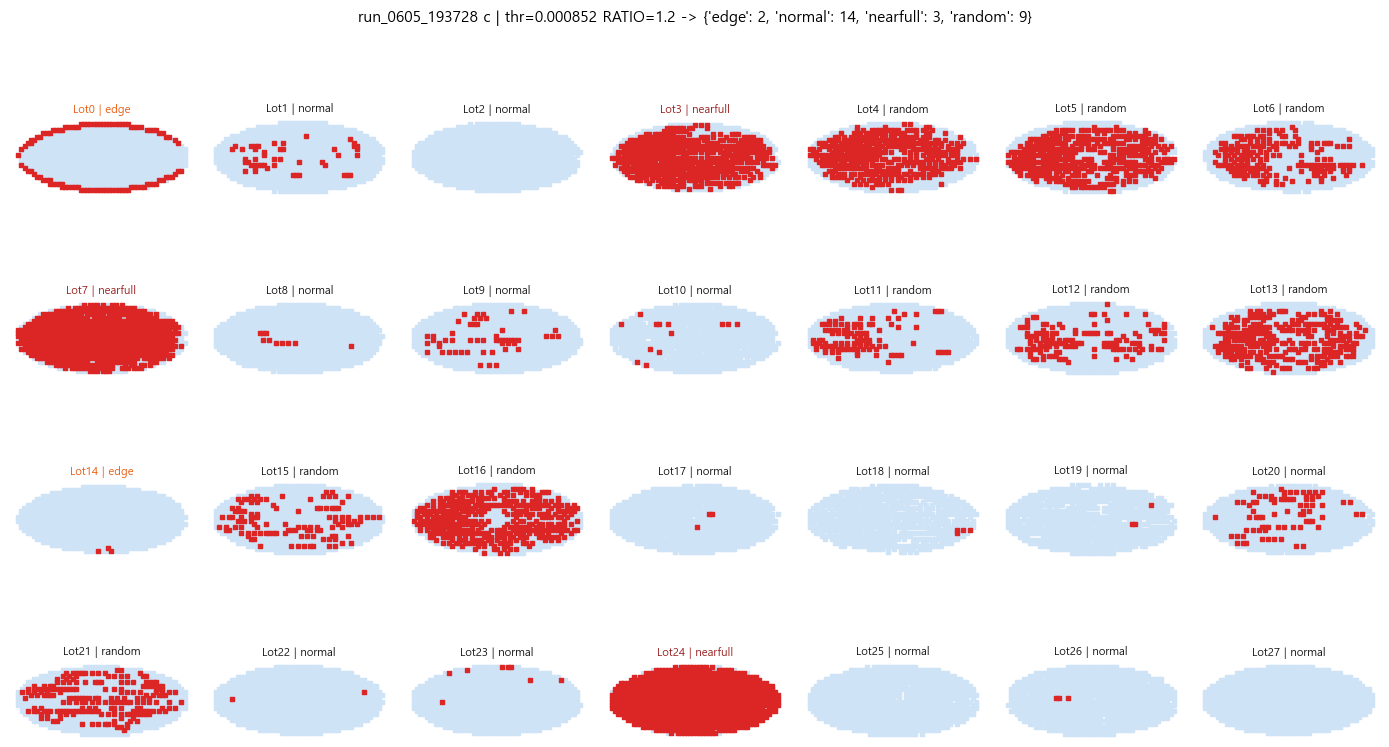

In [8]:
# 원하는 조합으로 맵 확인 (실험 결과 보고 값 조절)
EXP_RATIO = 1.2
EXP_THR_Q = 0.90
draw_lot_maps(threshold=float(die['pred'].quantile(EXP_THR_Q)), ratio=EXP_RATIO)

## Part B. 위험(상위10%) vs 안전(하위10%) 피처 분포

후보 모델의 unit 예측값(reg_pred) 상위10%(위험) vs 하위10%(안전) 그룹에서, gain 상위 X피처의 분포를 비교.

In [9]:
# unit reg_pred + gain 상위 X피처 (후보 fold_models.pkl 기준)
units = pd.concat([pd.read_csv(BEST / f'{s}_unit.csv') for s in ['oof', 'val', 'test']], ignore_index=True)
reg = units.dropna(subset=['pred']).set_index('ufs_serial')['pred']

ck = pickle.load(open(BEST / 'fold_models.pkl', 'rb'))
feat_names = ck['feature_names']
gain = np.zeros(len(feat_names))
for fm in ck['fold_models']:
    gain += fm.lgb_mu_.booster_.feature_importance(importance_type='gain')
gain /= len(ck['fold_models'])
_isx = lambda f: bool(re.match(r'^X\d+$', str(f)))
fi = pd.DataFrame({'feature': feat_names, 'gain': gain})
TOP_FEATS = fi[fi.feature.map(_isx)].sort_values('gain', ascending=False).head(6)['feature'].tolist()
print('gain 상위 X피처:', TOP_FEATS)
p90, p10 = float(reg.quantile(0.90)), float(reg.quantile(0.10))
print(f'reg_pred P90={p90:.6f}  P10={p10:.6f}')

gain 상위 X피처: ['X1064', 'X1066', 'X1060', 'X1070', 'X1071', 'X592']
reg_pred P90=0.003499  P10=0.000306


c:\Users\Dell3571\anaconda3\envs\wholebody\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator IsotonicRegression from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [10]:
# xs에서 position=1 대표값만 로드 (상위 피처 컬럼만 → 빠름)
cols = ['ufs_serial', 'position'] + TOP_FEATS
xs = pd.read_csv(XS_PATH, usecols=cols)
xs1 = xs[xs['position'] == 1].drop(columns='position').drop_duplicates('ufs_serial').set_index('ufs_serial')
xs1['reg_pred'] = reg.reindex(xs1.index)
xs1 = xs1.dropna(subset=['reg_pred'])
print('매칭 unit:', len(xs1))

매칭 unit: 43643


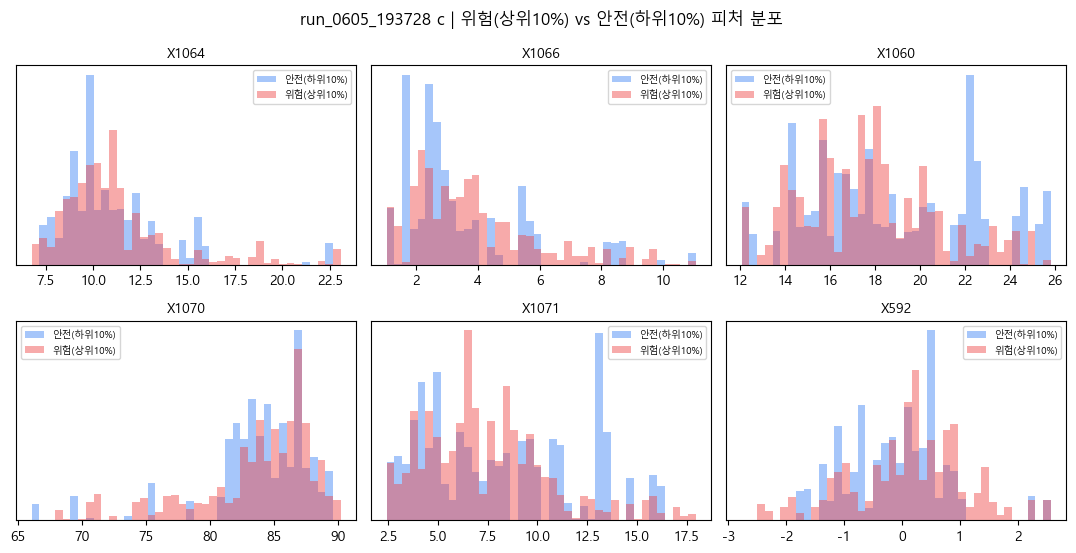

In [11]:
# 위험(상위10%) vs 안전(하위10%) 분포 비교
def plot_dist(feat, ax):
    df = xs1[[feat, 'reg_pred']].dropna()
    hi = df[df.reg_pred >= p90][feat].values
    lo = df[df.reg_pred <= p10][feat].values
    allv = np.r_[hi, lo]
    if len(allv) == 0:
        ax.set_title(f'{feat} (데이터 없음)', fontsize=9); return
    mn, mx = np.quantile(allv, 0.01), np.quantile(allv, 0.99)
    bins = np.linspace(mn, mx, 41) if mx > mn else 41
    ax.hist(lo, bins=bins, density=True, alpha=0.45, color='#3B82F6', label='안전(하위10%)')
    ax.hist(hi, bins=bins, density=True, alpha=0.45, color='#EF4444', label='위험(상위10%)')
    ax.set_title(feat, fontsize=10); ax.legend(fontsize=7); ax.set_yticks([])

ncols = 3; nrows = int(np.ceil(len(TOP_FEATS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.6, nrows * 2.8))
axes = np.atleast_1d(axes).ravel()
for ax in axes:
    ax.axis('off')
for ax, feat in zip(axes, TOP_FEATS):
    ax.axis('on'); plot_dist(feat, ax)
plt.suptitle(f'{BEST.parent.name} | 위험(상위10%) vs 안전(하위10%) 피처 분포', fontsize=12)
plt.tight_layout(); plt.show()